# Bangkok Final 4 Rain-Any Neighbor Models - TMD_DATA_MERGE

This notebook is based on `bkk_final_4_rain_any_neighbor_models.ipynb`, but it trains from PostgreSQL table `"TMD_DATA_MERGE"`.

`TMD_DATA_MERGE` contains raw TMD station observations rather than the precomputed Open-Meteo grid features, so this version builds the modeling table inside the notebook:

- standardizes TMD field names into model features
- adds wind direction encodings, lag features, rolling precipitation totals, and pressure changes
- creates nearest-station neighbor aggregate features
- creates `rain_any_next_1h`, `rain_any_next_2h`, `rain_any_next_3h`, and `rain_any_next_6h` targets from future station precipitation

Models trained:

- `1h`: LightGBM, recommended threshold `0.60`
- `2h`: LightGBM, recommended threshold `0.50`
- `3h`: HistGradientBoosting, recommended threshold `0.30`
- `6h`: HistGradientBoosting, recommended threshold `0.30`


## 1. Setup


In [1]:
import json
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")


## 2. Configuration


In [2]:
DB_CONFIG = {
    "host": os.getenv("PGHOST", "localhost"),
    "port": int(os.getenv("PGPORT", "5432")),
    "dbname": os.getenv("PGDATABASE", "postgres"),
    "user": os.getenv("PGUSER", "postgres"),
    "password": os.getenv("PGPASSWORD", "Pass1234"),
}

TABLE_NAME = '"TMD_DATA_MERGE"'
PROJECT_ROOT = Path.cwd()
MODEL_DIR = PROJECT_ROOT / "ML_Model_V2" / "trained_models" / "tmd_data_merge_rain_any_final_4_neighbor_models"

HORIZONS = [1, 2, 3, 6]
RAIN_THRESHOLD_MM = 0.1
PROBABILITY_THRESHOLDS_TO_TEST = np.arange(0.10, 0.91, 0.05)
RECOMMENDED_PROBABILITY_THRESHOLDS = {
    1: 0.60,
    2: 0.50,
    3: 0.30,
    6: 0.30,
}
MODEL_PLAN = {
    1: "lightgbm",
    2: "lightgbm",
    3: "hist_gradient_boosting",
    6: "hist_gradient_boosting",
}

TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
SAMPLE_ROWS = None  # Example for quick smoke tests: 300_000
RANDOM_STATE = 42
NEIGHBOR_COUNT = 5


## 3. TMD Feature Columns


In [3]:
RAW_TMD_FEATURE_COLUMNS = [
    "latitude",
    "longitude",
    "altitude_m",
    "temperature_c",
    "precipitation_mm",
    "pressure_hpa",
    "humidity_percent",
    "weather_code",
    "visibility_m",
    "wind_speed_avg_knot",
    "max_wind_speed_knot",
]

DERIVED_FEATURE_COLUMNS = [
    "wind_speed_avg_ms",
    "max_wind_speed_ms",
    "wind_dir_avg_sin",
    "wind_dir_avg_cos",
    "max_wind_dir_sin",
    "max_wind_dir_cos",
    "temperature_humidity_index",
    "temperature_dew_point_spread_est",
    "pressure_hpa_change_3h",
    "pressure_hpa_change_6h",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
]

LAG_FEATURE_COLUMNS = [
    "precipitation_lag_1h",
    "precipitation_lag_2h",
    "precipitation_lag_3h",
    "precipitation_lag_6h",
    "precipitation_sum_past_3h",
    "precipitation_sum_past_6h",
    "precipitation_sum_past_12h",
    "precipitation_sum_past_24h",
    "temperature_lag_1h",
    "temperature_lag_3h",
    "humidity_lag_1h",
    "humidity_lag_3h",
    "pressure_lag_1h",
    "pressure_lag_3h",
    "wind_speed_lag_1h",
    "wind_speed_lag_3h",
]

NEIGHBOR_FEATURE_COLUMNS = [
    "neighbor_count",
    "neighbor_precipitation_mean",
    "neighbor_precipitation_max",
    "neighbor_precipitation_sum",
    "neighbor_rain_count",
    "neighbor_rain_rate",
    "neighbor_temperature_mean",
    "neighbor_humidity_mean",
    "neighbor_pressure_mean",
    "neighbor_pressure_min",
    "neighbor_pressure_max",
    "neighbor_wind_speed_mean",
    "neighbor_wind_speed_max",
    "neighbor_visibility_mean",
    "neighbor_weather_code_mean",
    "neighbor_precipitation_mean_minus_center",
    "neighbor_temperature_mean_minus_center",
    "neighbor_humidity_mean_minus_center",
    "center_pressure_minus_neighbor_mean",
]

FEATURE_COLUMNS = RAW_TMD_FEATURE_COLUMNS + DERIVED_FEATURE_COLUMNS + LAG_FEATURE_COLUMNS + NEIGHBOR_FEATURE_COLUMNS
TARGET_COLUMNS = [f"rain_any_next_{horizon}h" for horizon in HORIZONS]

print(f"Features used: {len(FEATURE_COLUMNS)}")
print(f"Targets: {TARGET_COLUMNS}")


Features used: 60
Targets: ['rain_any_next_1h', 'rain_any_next_2h', 'rain_any_next_3h', 'rain_any_next_6h']


## 4. Load And Engineer TMD Training Data


In [4]:
def connect():
    return psycopg2.connect(**DB_CONFIG)


def inspect_table_columns():
    query = '''
    SELECT column_name, data_type
    FROM information_schema.columns
    WHERE table_schema = 'public'
      AND table_name = 'TMD_DATA_MERGE'
    ORDER BY ordinal_position
    '''
    with connect() as conn:
        return pd.read_sql_query(query, conn)


def read_raw_tmd_data(sample_rows=None):
    query = f'''
    SELECT
        utc_time,
        region,
        station,
        station_name,
        latitude,
        longitude,
        altitude_m,
        wind_dir_avg_deg,
        max_wind_dir_deg,
        wind_speed_avg_knot,
        max_wind_speed_knot,
        temperature_c,
        precipitation_mm,
        pressure_hpa,
        humidity_percent,
        weather_code,
        visibility_m,
        loaded_at
    FROM {TABLE_NAME}
    WHERE utc_time IS NOT NULL
      AND station IS NOT NULL
      AND latitude IS NOT NULL
      AND longitude IS NOT NULL
    '''
    if sample_rows:
        query = f'''
        SELECT *
        FROM ({query}) raw_rows
        LIMIT {int(sample_rows)}
        '''
    with connect() as conn:
        return pd.read_sql_query(query, conn, parse_dates=["utc_time", "loaded_at"])


def angular_sin(series):
    return np.sin(np.deg2rad(series.astype("float64")))


def angular_cos(series):
    return np.cos(np.deg2rad(series.astype("float64")))


def estimate_dew_point_c(temperature_c, humidity_percent):
    humidity = humidity_percent.clip(lower=1, upper=100)
    alpha = np.log(humidity / 100.0) + (17.625 * temperature_c) / (243.04 + temperature_c)
    return (243.04 * alpha) / (17.625 - alpha)


def add_station_time_features(raw):
    data = raw.copy()
    data["forecast_time"] = pd.to_datetime(data["utc_time"])
    data = data.sort_values(["station", "forecast_time"]).reset_index(drop=True)
    data["precipitation_mm"] = data["precipitation_mm"].clip(lower=0)
    data["wind_speed_avg_ms"] = data["wind_speed_avg_knot"] * 0.514444
    data["max_wind_speed_ms"] = data["max_wind_speed_knot"] * 0.514444
    data["wind_dir_avg_sin"] = angular_sin(data["wind_dir_avg_deg"])
    data["wind_dir_avg_cos"] = angular_cos(data["wind_dir_avg_deg"])
    data["max_wind_dir_sin"] = angular_sin(data["max_wind_dir_deg"])
    data["max_wind_dir_cos"] = angular_cos(data["max_wind_dir_deg"])
    data["temperature_humidity_index"] = data["temperature_c"] * (data["humidity_percent"] / 100.0)
    dew_point = estimate_dew_point_c(data["temperature_c"], data["humidity_percent"])
    data["temperature_dew_point_spread_est"] = data["temperature_c"] - dew_point

    hour = data["forecast_time"].dt.hour
    month = data["forecast_time"].dt.month
    data["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    data["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    data["month_sin"] = np.sin(2 * np.pi * month / 12)
    data["month_cos"] = np.cos(2 * np.pi * month / 12)

    grouped = data.groupby("station", group_keys=False)
    data["pressure_hpa_change_3h"] = grouped["pressure_hpa"].diff(3)
    data["pressure_hpa_change_6h"] = grouped["pressure_hpa"].diff(6)

    lag_specs = {
        "precipitation_lag_1h": ("precipitation_mm", 1),
        "precipitation_lag_2h": ("precipitation_mm", 2),
        "precipitation_lag_3h": ("precipitation_mm", 3),
        "precipitation_lag_6h": ("precipitation_mm", 6),
        "temperature_lag_1h": ("temperature_c", 1),
        "temperature_lag_3h": ("temperature_c", 3),
        "humidity_lag_1h": ("humidity_percent", 1),
        "humidity_lag_3h": ("humidity_percent", 3),
        "pressure_lag_1h": ("pressure_hpa", 1),
        "pressure_lag_3h": ("pressure_hpa", 3),
        "wind_speed_lag_1h": ("wind_speed_avg_knot", 1),
        "wind_speed_lag_3h": ("wind_speed_avg_knot", 3),
    }
    for output_column, (source_column, lag) in lag_specs.items():
        data[output_column] = grouped[source_column].shift(lag)

    for hours in [3, 6, 12, 24]:
        data[f"precipitation_sum_past_{hours}h"] = grouped["precipitation_mm"].transform(
            lambda s, window=hours: s.shift(1).rolling(window, min_periods=window).sum()
        )

    def future_rain_any(series, window):
        future_max = series.shift(-1).rolling(window, min_periods=window).max().shift(-(window - 1))
        return pd.Series(
            np.where(future_max.notna(), future_max >= RAIN_THRESHOLD_MM, np.nan),
            index=series.index,
            dtype="float",
        )

    for horizon in HORIZONS:
        data[f"rain_any_next_{horizon}h"] = grouped["precipitation_mm"].transform(
            lambda s, window=horizon: future_rain_any(s, window)
        )

    return data


def haversine_km(lat1, lon1, lat2, lon2):
    radius_km = 6371.0
    lat1 = np.deg2rad(lat1)
    lon1 = np.deg2rad(lon1)
    lat2 = np.deg2rad(lat2)
    lon2 = np.deg2rad(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * radius_km * np.arcsin(np.sqrt(a))


def build_neighbor_map(data, neighbor_count=NEIGHBOR_COUNT):
    stations = (
        data[["station", "latitude", "longitude"]]
        .dropna()
        .drop_duplicates("station")
        .reset_index(drop=True)
    )
    rows = []
    for station_row in stations.itertuples(index=False):
        distances = stations.copy()
        distances["distance_km"] = haversine_km(
            station_row.latitude,
            station_row.longitude,
            distances["latitude"],
            distances["longitude"],
        )
        neighbors = distances[distances["station"] != station_row.station].nsmallest(neighbor_count, "distance_km")
        for neighbor in neighbors.itertuples(index=False):
            rows.append({
                "station": station_row.station,
                "neighbor_station": neighbor.station,
                "neighbor_distance_km": float(neighbor.distance_km),
            })
    return pd.DataFrame(rows)


def add_neighbor_features(data):
    neighbor_map = build_neighbor_map(data)
    if neighbor_map.empty:
        raise RuntimeError("Need at least two stations to create neighbor features.")

    neighbor_values = data[[
        "forecast_time",
        "station",
        "precipitation_mm",
        "temperature_c",
        "humidity_percent",
        "pressure_hpa",
        "wind_speed_avg_knot",
        "visibility_m",
        "weather_code",
    ]].rename(columns={"station": "neighbor_station"})

    merged = neighbor_map.merge(neighbor_values, on="neighbor_station", how="left")
    merged["neighbor_is_rain"] = (merged["precipitation_mm"] >= RAIN_THRESHOLD_MM).astype("int8")
    neighbor_features = (
        merged.groupby(["forecast_time", "station"])
        .agg(
            neighbor_count=("neighbor_station", "nunique"),
            neighbor_precipitation_mean=("precipitation_mm", "mean"),
            neighbor_precipitation_max=("precipitation_mm", "max"),
            neighbor_precipitation_sum=("precipitation_mm", "sum"),
            neighbor_rain_count=("neighbor_is_rain", "sum"),
            neighbor_rain_rate=("neighbor_is_rain", "mean"),
            neighbor_temperature_mean=("temperature_c", "mean"),
            neighbor_humidity_mean=("humidity_percent", "mean"),
            neighbor_pressure_mean=("pressure_hpa", "mean"),
            neighbor_pressure_min=("pressure_hpa", "min"),
            neighbor_pressure_max=("pressure_hpa", "max"),
            neighbor_wind_speed_mean=("wind_speed_avg_knot", "mean"),
            neighbor_wind_speed_max=("wind_speed_avg_knot", "max"),
            neighbor_visibility_mean=("visibility_m", "mean"),
            neighbor_weather_code_mean=("weather_code", "mean"),
        )
        .reset_index()
    )

    out = data.merge(neighbor_features, on=["forecast_time", "station"], how="left")
    out["neighbor_precipitation_mean_minus_center"] = out["neighbor_precipitation_mean"] - out["precipitation_mm"]
    out["neighbor_temperature_mean_minus_center"] = out["neighbor_temperature_mean"] - out["temperature_c"]
    out["neighbor_humidity_mean_minus_center"] = out["neighbor_humidity_mean"] - out["humidity_percent"]
    out["center_pressure_minus_neighbor_mean"] = out["pressure_hpa"] - out["neighbor_pressure_mean"]
    return out, neighbor_map


def read_training_data(sample_rows=None):
    raw = read_raw_tmd_data(sample_rows)
    engineered = add_station_time_features(raw)
    engineered, neighbor_map = add_neighbor_features(engineered)

    required_columns = ["station", "forecast_time", *FEATURE_COLUMNS, *TARGET_COLUMNS]
    complete = engineered.dropna(subset=required_columns).copy()
    complete[TARGET_COLUMNS] = complete[TARGET_COLUMNS].astype("int8")
    complete = complete.sort_values(["forecast_time", "station"]).reset_index(drop=True)
    return complete, neighbor_map


In [5]:
table_columns = inspect_table_columns()
display(table_columns)


C:\Users\Brandon\AppData\Local\Temp\ipykernel_7756\2839968707.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)


,column_name,data_type
0,utc_time,timestamp without time zone
1,region,text
2,station,text
3,station_name,text
4,latitude,double precision
5,longitude,double precision
6,altitude_m,double precision
7,raw_sectime,text
8,wind_dir_avg_deg,double precision
9,max_wind_dir_deg,double precision


In [6]:
df, neighbor_map = read_training_data(SAMPLE_ROWS)
print(df.shape)
print(df["forecast_time"].min(), "to", df["forecast_time"].max())
print(f"Stations: {df['station'].nunique()}")
display(df.head())
display(neighbor_map.head(20))

required_columns = sorted(set(FEATURE_COLUMNS + TARGET_COLUMNS))
missing_counts = df[required_columns].isna().sum().sort_values(ascending=False)
display(missing_counts[missing_counts > 0])


C:\Users\Brandon\AppData\Local\Temp\ipykernel_7756\2839968707.py:51: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn, parse_dates=["utc_time", "loaded_at"])


(1826881, 72)
2020-01-15 18:00:00 to 2026-06-30 18:00:00
Stations: 85


,utc_time,region,station,station_name,latitude,longitude,altitude_m,wind_dir_avg_deg,max_wind_dir_deg,wind_speed_avg_knot,max_wind_speed_knot,temperature_c,precipitation_mm,pressure_hpa,humidity_percent,weather_code,visibility_m,loaded_at,forecast_time,wind_speed_avg_ms,max_wind_speed_ms,wind_dir_avg_sin,wind_dir_avg_cos,max_wind_dir_sin,max_wind_dir_cos,temperature_humidity_index,temperature_dew_point_spread_est,hour_sin,hour_cos,month_sin,month_cos,pressure_hpa_change_3h,pressure_hpa_change_6h,precipitation_lag_1h,precipitation_lag_2h,precipitation_lag_3h,precipitation_lag_6h,temperature_lag_1h,temperature_lag_3h,humidity_lag_1h,humidity_lag_3h,pressure_lag_1h,pressure_lag_3h,wind_speed_lag_1h,wind_speed_lag_3h,precipitation_sum_past_3h,precipitation_sum_past_6h,precipitation_sum_past_12h,precipitation_sum_past_24h,rain_any_next_1h,rain_any_next_2h,rain_any_next_3h,rain_any_next_6h,neighbor_count,neighbor_precipitation_mean,neighbor_precipitation_max,neighbor_precipitation_sum,neighbor_rain_count,neighbor_rain_rate,neighbor_temperature_mean,neighbor_humidity_mean,neighbor_pressure_mean,neighbor_pressure_min,neighbor_pressure_max,neighbor_wind_speed_mean,neighbor_wind_speed_max,neighbor_visibility_mean,neighbor_weather_code_mean,neighbor_precipitation_mean_minus_center,neighbor_temperature_mean_minus_center,neighbor_humidity_mean_minus_center,center_pressure_minus_neighbor_mean
0,2020-01-15 18:00:00,1,28,Kampaeng Saen Agrometeorlogical Station,14.011666,99.96972,8.96,159.110001,135.0,0.421667,1.7,23.768333,0.0,1011.180008,95.530000,0.0,0.000000,2026-06-26 14:41:11.253153,2020-01-15 18:00:00,0.216924,0.874555,0.356575,-0.934267,0.707107,-0.707107,22.705889,0.757803,-1.0,-1.836970e-16,0.5,0.866025,0.249999,1.518351,0.0,0.0,0.0,0.0,23.698333,25.250000,93.865000,77.916667,1011.179995,1010.930009,0.525,0.670000,0.0,0.0,0.0,0.0,0,0,0,0,2.0,0.0,0.0,0.0,0.0,0.0,24.737500,77.927500,1008.816672,1006.900014,1010.733329,0.395000,0.790000,0.000000,0.0,0.0,0.969167,-17.602500,2.363336
1,2020-01-15 18:00:00,1,31,Kanchanaburi Weather Observing Station,14.022500,99.53611,28.00,228.293333,298.1,0.790000,1.9,25.233333,0.0,1006.900014,70.653333,0.0,0.000000,2026-06-26 14:51:21.442528,2020-01-15 18:00:00,0.406411,0.977444,-0.746561,-0.665317,-0.882127,0.471012,17.828191,5.712311,-1.0,-1.836970e-16,0.5,0.866025,0.201692,1.660013,0.0,0.0,0.0,0.0,25.361666,26.766667,71.306666,60.316667,1006.903353,1006.698323,0.360,0.448333,0.0,0.0,0.0,0.0,0,0,0,0,2.0,0.0,0.0,0.0,0.0,0.0,24.005000,90.365833,1010.956669,1010.733329,1011.180008,0.210833,0.421667,0.000000,0.0,0.0,-1.228333,19.712500,-4.056654
2,2020-01-15 18:00:00,1,32,Ratcha Buri Agrometeorlogical Station,13.489445,99.79222,3.00,207.056667,236.3,0.000000,0.9,24.241667,0.0,1010.733329,85.201666,0.0,0.000000,2026-06-26 14:56:31.970024,2020-01-15 18:00:00,0.000000,0.463000,-0.454872,-0.890557,-0.831954,-0.554844,20.654304,2.644466,-1.0,-1.836970e-16,0.5,0.866025,0.001665,1.331658,0.0,0.0,0.0,0.0,25.243333,26.768333,82.660000,78.226666,1010.769999,1010.731664,0.000,0.011667,0.0,0.0,0.0,0.0,0,0,0,0,2.0,0.0,0.0,0.0,0.0,0.0,24.500833,83.091667,1009.040011,1006.900014,1011.180008,0.605833,0.790000,0.000000,0.0,0.0,0.259166,-2.110000,1.693318
3,2020-01-15 18:00:00,1,33,Pratumtani Agrometeorlogical Station,14.116111,100.62055,8.00,173.803333,163.1,0.960000,3.2,26.600000,0.0,1010.813333,82.028333,0.0,0.000000,2026-06-26 15:02:01.012902,2020-01-15 18:00:00,0.493866,1.646221,0.107942,-0.994157,0.290702,-0.956814,21.819537,3.321054,-1.0,-1.836970e-16,0.5,0.866025,0.096670,1.431667,0.0,0.0,0.0,0.0,26.920000,28.175000,76.281666,64.595000,1010.693329,1010.716664,1.215,0.901667,0.0,0.0,0.0,0.0,0,0,0,0,2.0,0.0,0.0,0.0,0.0,0.0,25.501667,92.421667,1010.929993,1010.596657,1011.263329,0.990833,1.101667,12226.383333,0.0,0.0,-1.098333,10.393333,-0.116660
4,2020-01-15 18:00:00,1,37,Bangna Agrometeorlogical Station,13.667500,100.60528,5.00,188.636667,199.7,1.101667,2.8,26.608334,0.0,1011.263329,86.641667,0.0,12226.383333,2026-0

,station,neighbor_station,neighbor_distance_km
0,1,1018,5.421786
1,1,1020,11.766229
2,1,9,23.842629
3,1,16,60.697383
4,1,1019,65.637414
5,10,1007,59.428647
6,10,1019,64.054751
7,10,1021,65.118643
8,10,1005,76.646222
9,10,1008,81.081207


Series([], dtype: int64)

## 5. Target Balance


,horizon_h,target_column,rain_threshold_mm,rows,rain_rows,rain_rate
0,1,rain_any_next_1h,0.1,1826881,106344,0.058211
1,2,rain_any_next_2h,0.1,1826881,152989,0.083743
2,3,rain_any_next_3h,0.1,1826881,191641,0.104901
3,6,rain_any_next_6h,0.1,1826881,285571,0.156316


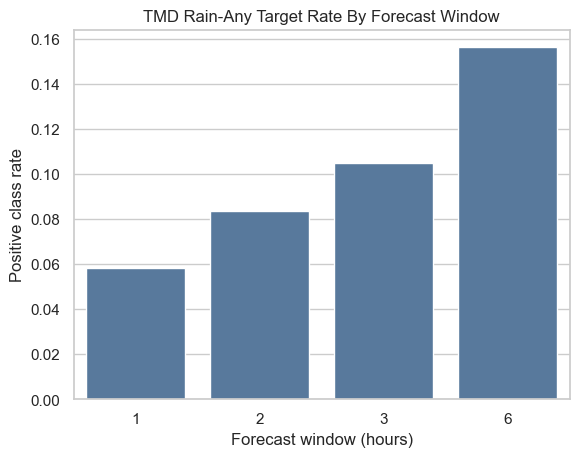

In [7]:
target_balance = pd.DataFrame([
    {
        "horizon_h": horizon,
        "target_column": f"rain_any_next_{horizon}h",
        "rain_threshold_mm": RAIN_THRESHOLD_MM,
        "rows": len(df),
        "rain_rows": int(df[f"rain_any_next_{horizon}h"].sum()),
        "rain_rate": float(df[f"rain_any_next_{horizon}h"].mean()),
    }
    for horizon in HORIZONS
])
display(target_balance)

sns.barplot(data=target_balance, x="horizon_h", y="rain_rate", color="#4c78a8")
plt.title("TMD Rain-Any Target Rate By Forecast Window")
plt.xlabel("Forecast window (hours)")
plt.ylabel("Positive class rate")
plt.show()


## 6. Chronological Split


In [8]:
def add_time_split(data, train_fraction=0.70, validation_fraction=0.15):
    unique_times = np.array(sorted(data["forecast_time"].unique()))
    if len(unique_times) < 4:
        raise RuntimeError("Not enough timestamps to create train/validation/test splits.")
    train_end = unique_times[max(1, int(len(unique_times) * train_fraction))]
    validation_end = unique_times[max(2, int(len(unique_times) * (train_fraction + validation_fraction)))]
    out = data.copy()
    out["split"] = "test"
    out.loc[out["forecast_time"] < train_end, "split"] = "train"
    out.loc[(out["forecast_time"] >= train_end) & (out["forecast_time"] < validation_end), "split"] = "validation"
    return out, train_end, validation_end

model_df, train_end, validation_end = add_time_split(df, TRAIN_FRACTION, VALIDATION_FRACTION)
print(f"Train before: {train_end}")
print(f"Validation before: {validation_end}")
display(model_df.groupby("split").size().rename("rows").reset_index())

train_df = model_df[model_df["split"] == "train"]
validation_df = model_df[model_df["split"] == "validation"]
test_df = model_df[model_df["split"] == "test"]

x_train = train_df[FEATURE_COLUMNS].astype("float32")
x_validation = validation_df[FEATURE_COLUMNS].astype("float32")
x_test = test_df[FEATURE_COLUMNS].astype("float32")


Train before: 2025-05-12 09:00:00
Validation before: 2025-12-05 14:00:00


,split,rows
0,test,312003
1,train,1137790
2,validation,377088


## 7. Evaluation Helpers


In [9]:
def threshold_metrics(y_true, probabilities, thresholds=PROBABILITY_THRESHOLDS_TO_TEST):
    rows = []
    for threshold in thresholds:
        y_pred = (probabilities >= threshold).astype("int8")
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        rows.append({
            "probability_threshold": float(threshold),
            "predicted_rain_rate": float(y_pred.mean()),
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "precision": float(precision_score(y_true, y_pred, zero_division=0)),
            "recall": float(recall_score(y_true, y_pred, zero_division=0)),
            "f1": float(f1_score(y_true, y_pred, zero_division=0)),
            "true_negatives": int(tn),
            "false_positives": int(fp),
            "false_negatives": int(fn),
            "true_positives": int(tp),
        })
    return pd.DataFrame(rows)


def evaluate_probabilities(y_true, probabilities, model_name, horizon, split):
    base = {
        "model": model_name,
        "feature_set": "tmd_station_neighbor",
        "horizon_h": horizon,
        "split": split,
        "rows": int(len(y_true)),
        "rain_rate": float(np.mean(y_true)),
        "roc_auc": float(roc_auc_score(y_true, probabilities)),
        "pr_auc": float(average_precision_score(y_true, probabilities)),
        "brier_score": float(brier_score_loss(y_true, probabilities)),
    }
    threshold_df = threshold_metrics(y_true, probabilities)
    for key, value in base.items():
        threshold_df[key] = value
    return base, threshold_df


def best_thresholds(threshold_results):
    return (
        threshold_results.sort_values(["model", "horizon_h", "split", "f1"], ascending=[True, True, True, False])
        .groupby(["model", "horizon_h", "split"], as_index=False)
        .head(1)
        .sort_values(["model", "horizon_h", "split"])
    )


def metrics_at_recommended_threshold(threshold_results):
    rows = []
    for horizon, threshold in RECOMMENDED_PROBABILITY_THRESHOLDS.items():
        model_name = MODEL_PLAN[horizon]
        selected = threshold_results[
            (threshold_results["horizon_h"] == horizon)
            & (threshold_results["model"] == model_name)
            & (threshold_results["probability_threshold"].round(10) == round(threshold, 10))
        ]
        rows.append(selected)
    return pd.concat(rows, ignore_index=True)


## 8. Train Final 4 Models


In [10]:
try:
    from lightgbm import LGBMClassifier
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("Install LightGBM first: %pip install lightgbm") from exc

models = {}
metric_rows = []
threshold_tables = []
feature_importance_rows = []

for horizon in HORIZONS:
    model_name = MODEL_PLAN[horizon]
    target = f"rain_any_next_{horizon}h"
    print(f"Training {model_name} for {target}...")

    y_train = train_df[target].astype("int8")
    y_validation = validation_df[target].astype("int8")
    y_test = test_df[target].astype("int8")

    if model_name == "lightgbm":
        scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
        model = LGBMClassifier(
            objective="binary",
            n_estimators=500,
            learning_rate=0.04,
            num_leaves=63,
            min_child_samples=80,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=1.0,
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        model.fit(
            x_train,
            y_train,
            eval_set=[(x_validation, y_validation)],
            eval_metric="binary_logloss",
        )
        for feature, importance in zip(FEATURE_COLUMNS, model.feature_importances_):
            feature_importance_rows.append({
                "model": model_name,
                "horizon_h": horizon,
                "feature": feature,
                "importance": float(importance),
                "is_neighbor_feature": feature in NEIGHBOR_FEATURE_COLUMNS,
            })
    elif model_name == "hist_gradient_boosting":
        model = HistGradientBoostingClassifier(
            learning_rate=0.06,
            max_iter=250,
            max_leaf_nodes=31,
            l2_regularization=0.05,
            random_state=RANDOM_STATE,
        )
        model.fit(x_train, y_train)
    else:
        raise ValueError(f"Unsupported model type: {model_name}")

    models[horizon] = model

    for split_name, x_split, y_split in [
        ("validation", x_validation, y_validation),
        ("test", x_test, y_test),
    ]:
        probabilities = model.predict_proba(x_split)[:, 1]
        metrics, thresholds = evaluate_probabilities(y_split.to_numpy(), probabilities, model_name, horizon, split_name)
        metric_rows.append(metrics)
        threshold_tables.append(thresholds)

all_metrics = pd.DataFrame(metric_rows)
all_threshold_results = pd.concat(threshold_tables, ignore_index=True)
best_by_f1 = best_thresholds(all_threshold_results)
recommended_threshold_metrics = metrics_at_recommended_threshold(all_threshold_results)
feature_importance = pd.DataFrame(feature_importance_rows)

display(all_metrics.sort_values(["horizon_h", "split"]))
display(best_by_f1[best_by_f1["split"] == "test"].sort_values("horizon_h"))
display(recommended_threshold_metrics[recommended_threshold_metrics["split"] == "test"].sort_values("horizon_h"))


Training lightgbm for rain_any_next_1h...
[LightGBM] [Info] Number of positive: 55887, number of negative: 1081903
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.653626 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12794
[LightGBM] [Info] Number of data points in the train set: 1137790, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.049119 -> initscore=-2.963145
[LightGBM] [Info] Start training from score -2.963145
Training lightgbm for rain_any_next_2h...
[LightGBM] [Info] Number of positive: 80273, number of negative: 1057517
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.638910 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12794
[LightGBM] [Info] Number of data points in the train set: 1137790, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.07

,model,feature_set,horizon_h,split,rows,rain_rate,roc_auc,pr_auc,brier_score
1,lightgbm,tmd_station_neighbor,1,test,312003,0.033365,0.934829,0.515631,0.067736
0,lightgbm,tmd_station_neighbor,1,validation,377088,0.106201,0.894105,0.632245,0.188116
3,lightgbm,tmd_station_neighbor,2,test,312003,0.050166,0.915951,0.506751,0.083556
2,lightgbm,tmd_station_neighbor,2,validation,377088,0.151328,0.864034,0.630918,0.215939
5,hist_gradient_boosting,tmd_station_neighbor,3,test,312003,0.064679,0.903501,0.508110,0.042847
4,hist_gradient_boosting,tmd_station_neighbor,3,validation,377088,0.188460,0.842672,0.635590,0.105267
7,hist_gradient_boosting,tmd_station_neighbor,6,test,312003,0.101323,0.885139,0.529720,0.065121
6,hist_gradient_boosting,tmd_station_neighbor,6,validation,377088,0.277169,0.812883,0.667101,0.145122


,probability_threshold,predicted_rain_rate,accuracy,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives,model,feature_set,horizon_h,split,rows,rain_rate,roc_auc,pr_auc,brier_score
32,0.85,0.032282,0.968276,0.525417,0.508357,0.516746,296813,4780,5118,5292,lightgbm,tmd_station_neighbor,1,test,312003,0.033365,0.934829,0.515631,0.067736
65,0.80,0.049092,0.949388,0.495463,0.484858,0.490103,288623,7728,8063,7589,lightgbm,tmd_station_neighbor,2,test,312003,0.050166,0.915951,0.506751,0.083556
88,0.25,0.063067,0.934408,0.492758,0.480476,0.486539,281842,9981,10484,9696,hist_gradient_boosting,tmd_station_neighbor,3,test,312003,0.064679,0.903501,0.508110,0.042847
122,0.25,0.117140,0.891209,0.468124,0.541201,0.502017,260951,19439,14504,17109,hist_gradient_boosting,tmd_station_neighbor,6,test,312003,0.101323,0.885139,0.529720,0.065121


,probability_threshold,predicted_rain_rate,accuracy,precision,recall,f1,true_negatives,false_positives,false_negatives,true_positives,model,feature_set,horizon_h,split,rows,rain_rate,roc_auc,pr_auc,brier_score
1,0.6,0.084804,0.929741,0.282475,0.717963,0.405435,282608,18985,2936,7474,lightgbm,tmd_station_neighbor,1,test,312003,0.033365,0.934829,0.515631,0.067736
3,0.5,0.147322,0.878665,0.258458,0.759008,0.385608,262266,34085,3772,11880,lightgbm,tmd_station_neighbor,2,test,312003,0.050166,0.915951,0.506751,0.083556
5,0.3,0.050721,0.939985,0.545972,0.428147,0.479933,284638,7185,11540,8640,hist_gradient_boosting,tmd_station_neighbor,3,test,312003,0.064679,0.903501,0.508110,0.042847
7,0.3,0.089778,0.902437,0.520938,0.461582,0.489467,266971,13419,17021,14592,hist_gradient_boosting,tmd_station_neighbor,6,test,312003,0.101323,0.885139,0.529720,0.065121


## 9. Results Charts


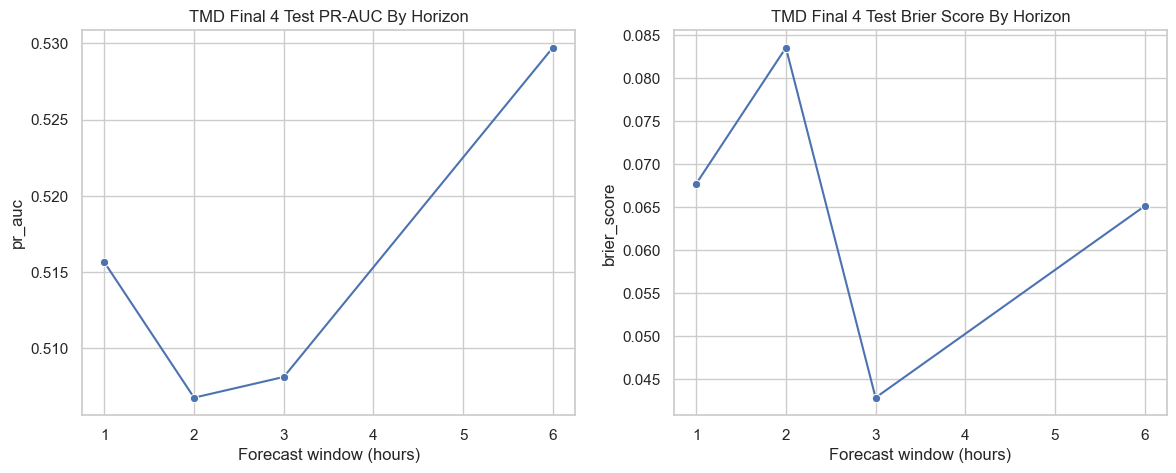

,model,horizon_h,feature,importance,is_neighbor_feature
48,lightgbm,1,neighbor_humidity_mean,1112.0,True
19,lightgbm,1,pressure_hpa_change_3h,984.0,False
47,lightgbm,1,neighbor_temperature_mean,930.0,True
10,lightgbm,1,max_wind_speed_knot,912.0,False
20,lightgbm,1,pressure_hpa_change_6h,862.0,False
57,lightgbm,1,neighbor_temperature_mean_minus_center,862.0,True
17,lightgbm,1,temperature_humidity_index,859.0,False
3,lightgbm,1,temperature_c,857.0,False
52,lightgbm,1,neighbor_wind_speed_mean,856.0,True
1,lightgbm,1,longitude,850.0,False


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
sns.lineplot(data=all_metrics[all_metrics["split"] == "test"], x="horizon_h", y="pr_auc", marker="o", ax=axes[0])
axes[0].set_title("TMD Final 4 Test PR-AUC By Horizon")
sns.lineplot(data=all_metrics[all_metrics["split"] == "test"], x="horizon_h", y="brier_score", marker="o", ax=axes[1])
axes[1].set_title("TMD Final 4 Test Brier Score By Horizon")
for ax in axes:
    ax.set_xlabel("Forecast window (hours)")
plt.show()

if not feature_importance.empty:
    top_importance = feature_importance.sort_values(["horizon_h", "importance"], ascending=[True, False]).groupby("horizon_h").head(20)
    display(top_importance)


## 10. Save Final Models And Results


In [12]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)

for horizon, model in models.items():
    model_name = MODEL_PLAN[horizon]
    threshold = RECOMMENDED_PROBABILITY_THRESHOLDS[horizon]
    path = MODEL_DIR / f"tmd_rain_any_next_{horizon}h_neighbor_station_{model_name}_prob_threshold_{threshold:g}_rain_threshold_{RAIN_THRESHOLD_MM:g}mm.joblib"
    joblib.dump(model, path)

target_balance.to_csv(MODEL_DIR / "tmd_final_4_target_balance.csv", index=False)
all_metrics.to_csv(MODEL_DIR / "tmd_final_4_metrics.csv", index=False)
all_threshold_results.to_csv(MODEL_DIR / "tmd_final_4_probability_thresholds.csv", index=False)
best_by_f1.to_csv(MODEL_DIR / "tmd_final_4_best_thresholds_by_f1.csv", index=False)
recommended_threshold_metrics.to_csv(MODEL_DIR / "tmd_final_4_recommended_threshold_metrics.csv", index=False)
neighbor_map.to_csv(MODEL_DIR / "tmd_neighbor_station_map.csv", index=False)
if not feature_importance.empty:
    feature_importance.to_csv(MODEL_DIR / "tmd_final_4_lightgbm_feature_importance.csv", index=False)

metadata = {
    "table": TABLE_NAME,
    "target_type": "rain_any_within_next_n_hours",
    "model_plan": MODEL_PLAN,
    "recommended_probability_thresholds": RECOMMENDED_PROBABILITY_THRESHOLDS,
    "horizons": HORIZONS,
    "rain_threshold_mm": RAIN_THRESHOLD_MM,
    "neighbor_count": NEIGHBOR_COUNT,
    "feature_columns": FEATURE_COLUMNS,
    "raw_tmd_feature_columns": RAW_TMD_FEATURE_COLUMNS,
    "derived_feature_columns": DERIVED_FEATURE_COLUMNS,
    "lag_feature_columns": LAG_FEATURE_COLUMNS,
    "neighbor_feature_columns": NEIGHBOR_FEATURE_COLUMNS,
    "target_columns": TARGET_COLUMNS,
    "train_end_exclusive": str(train_end),
    "validation_end_exclusive": str(validation_end),
    "sample_rows": SAMPLE_ROWS,
    "model_dir": str(MODEL_DIR),
    "target_balance": target_balance.to_dict(orient="records"),
    "metrics": all_metrics.to_dict(orient="records"),
    "best_thresholds_by_f1": best_by_f1.to_dict(orient="records"),
    "recommended_threshold_metrics": recommended_threshold_metrics.to_dict(orient="records"),
}
(MODEL_DIR / "tmd_final_4_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"Saved TMD final 4 models and result CSVs to {MODEL_DIR}")


Saved TMD final 4 models and result CSVs to C:\Users\Brandon\Documents\Phase 1\ML_Model_V2\trained_models\tmd_data_merge_rain_any_final_4_neighbor_models
